In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("loan_approval.csv")
df.head(15)

,age,annual_income,loan_amount,credit_score,employment_years,credit_card_count,late_payment_count,debt_income_ratio,savings_balance,property_value,dependents_count,city_tier,loan_status
0,56,121520,6141,507,12,4,1,0.46,72610,330446,0,2,1
1,46,145818,23019,307,2,9,8,0.69,52500,378380,4,2,1
2,32,81272,25384,828,2,4,14,0.39,40618,114467,4,2,1
3,60,112152,47903,465,23,0,0,0.12,26444,414494,5,2,1
4,25,142907,41129,795,4,5,8,0.18,86982,478057,3,3,1
5,38,87649,27967,889,25,8,0,0.50,95079,487929,3,2,1
6,56,84674,45603,728,10,1,14,0.65,57586,492762,4,3,1
7,36,144132,16172,462,29,6,13,0.37,25789,305908,5,2,1
8,40,139044,21390,665,6,5,6,0.66,2617,315192,4,3,1
9,28,128542,8267,825,20,4,5,0.66,4333,299212,5,3,1


In [3]:
df.columns

Index(['age', 'annual_income', 'loan_amount', 'credit_score',
       'employment_years', 'credit_card_count', 'late_payment_count',
       'debt_income_ratio', 'savings_balance', 'property_value',
       'dependents_count', 'city_tier', 'loan_status'],
      dtype='object')

In [4]:
df.shape

(2000, 13)

In [5]:
df.isnull().sum()

age                   0
annual_income         0
loan_amount           0
credit_score          0
employment_years      0
credit_card_count     0
late_payment_count    0
debt_income_ratio     0
savings_balance       0
property_value        0
dependents_count      0
city_tier             0
loan_status           0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [7]:
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = LogisticRegression(penalty=None)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [10]:
print("logistic regression (No Penalty)")
print(confusion_matrix(y_test,y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("f1 score:",f1_score(y_test, y_pred))
print("aur_roc:",roc_auc_score(y_test, y_pred))


logistic regression (No Penalty)
[[ 25   2]
 [  1 372]]
Accuracy: 0.9925
Precision: 0.9946524064171123
Recall: 0.9973190348525469
f1 score: 0.9959839357429718
aur_roc: 0.9616224803892365


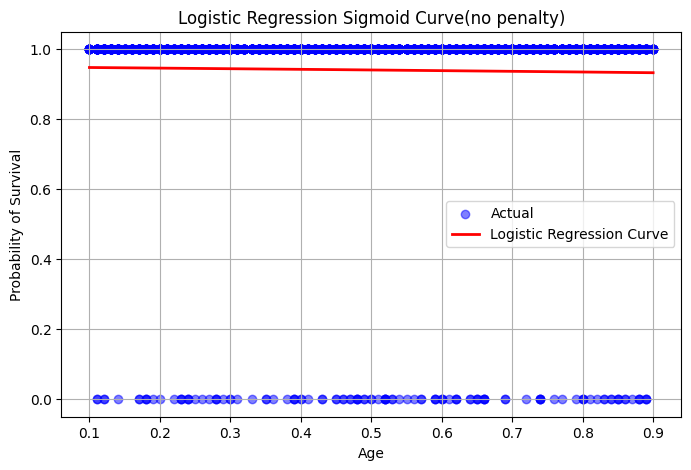

In [11]:
X_single = df[['debt_income_ratio']].values  # feature must be 2D
y = df['loan_status']

# Fit logistic regression
model = LogisticRegression()
model.fit(X_single, y)

# Generate values for plotting
X_plot = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1,1)
y_prob = model.predict_proba(X_plot)[:,1]

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_single, y, color='blue', alpha=0.5, label='Actual')
plt.plot(X_plot, y_prob, color='red', linewidth=2, label='Logistic Regression Curve')
plt.xlabel('Age')
plt.ylabel('Probability of Survival')
plt.title('Logistic Regression Sigmoid Curve(no penalty)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
model_l1 = LogisticRegression(penalty='l1',solver='liblinear',max_iter=1000)

model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)

In [13]:
print("logistic regression (Penalty=l1)")
print(confusion_matrix(y_test,y_pred_l1))
print("Accuracy:", accuracy_score(y_test, y_pred_l1))
print("Precision:", precision_score(y_test, y_pred_l1))
print("Recall:", recall_score(y_test, y_pred_l1))
print("f1 score:",f1_score(y_test, y_pred_l1))
print("aur_roc:",roc_auc_score(y_test, y_pred_l1))

logistic regression (Penalty=l1)
[[ 23   4]
 [  1 372]]
Accuracy: 0.9875
Precision: 0.9893617021276596
Recall: 0.9973190348525469
f1 score: 0.9933244325767691
aur_roc: 0.9245854433521994


In [14]:
model_l2 = LogisticRegression(penalty='l2',max_iter=1000)

model_l2.fit(X_train, y_train)

y_pred_l2 = model_l2.predict(X_test)

In [15]:
print("logistic regression (Penalty=l2)")
print(confusion_matrix(y_test,y_pred_l2))
print("Accuracy:", accuracy_score(y_test, y_pred_l2))
print("Precision:", precision_score(y_test, y_pred_l2))
print("Recall:", recall_score(y_test, y_pred_l2))
print("f1 score:",f1_score(y_test, y_pred_l2))
print("aur_roc:",roc_auc_score(y_test, y_pred_l2))

logistic regression (Penalty=l2)
[[ 16  11]
 [  0 373]]
Accuracy: 0.9725
Precision: 0.9713541666666666
Recall: 1.0
f1 score: 0.9854689564068693
aur_roc: 0.7962962962962963
